In [ ]:
!pip install scanpy
!pip install scvi-tools
!pip install leidenalg
!pip install soupx-python
!pip install celltypist

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
import anndata
import leidenalg
import scvi
import soupx;
import celltypist
from celltypist import models

In [ ]:
adata = sc.read_10x_mtx("/content/PBMC10k-filtered", var_names="gene_symbols", cache=True)
adata_raw = sc.read_10x_mtx("/content/PBMC10K-raw", var_names="gene_symbols", cache=True)
adata.var_names_make_unique()
adata_raw.var_names_make_unique()

In [ ]:
print(f'The shape of the filtered file: {adata.X.shape}')
print(f'The shape of the raw file: {adata_raw.X.shape}')

#saving a copy of the data before running soupx
adata.layers["before_soupx"] = adata.X.copy()

In [ ]:
#running soupx for ambient rna removal
#soupx works best with clusters
temp = adata.copy()
sc.pp.normalize_total(temp, target_sum = 1e4)
sc.pp.log1p(temp)
sc.pp.pca(temp)
sc.pp.neighbors(temp)
sc.tl.leiden(temp, key_added = "soupx_groups", flavor = "igraph", n_iterations = 2, directed = False)

In [ ]:
#transfer the clusters column "soupx_groups" to adata and run soupx
adata.obs["soupx_groups"] = temp.obs["soupx_groups"]
del temp
soup_channel = soupx.SoupChannel(tod = adata_raw.X.T.tocsr(),
                                 toc = adata.X.T.tocsr(),
                                 metadata = pd.DataFrame(index = adata.obs_names))
soup_channel.setClusters(adata.obs["soupx_groups"].values)
soup_channel = soupx.autoEstCont(soup_channel, verbose = False)
corrected_matrix = soupx.adjustCounts(soup_channel)

Adjusting counts using method 'subtraction' with 24 clusters
Using subtraction method


/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Expanding counts from 24 clusters to 11769 cells (vectorized)


In [ ]:
#save a copy of the adata with soupx_groups and with ambient rna, and a copy of the corrected matrix then make the corrected matrix the default X
adata.layers["with_soup_groups_and_ambient_rna"] = adata.X.copy()
adata.layers["corrected_matrix"] = corrected_matrix.T
adata.X = corrected_matrix.T

In [ ]:
#light qc filtering
sc.pp.filter_cells(adata, min_genes = 200)
sc.pp.filter_genes(adata, min_cells = 10)
adata.X.shape

(11536, 17526)

In [ ]:
#performing doublet detection with scvi
adata_hvg = adata.copy() #making a copy of adata to subset hvg for scvi training, this will reduce the noise for scvi
sc.pp.highly_variable_genes(adata_hvg, n_top_genes = 3000, subset = True, flavor = 'seurat_v3')
scvi.model.SCVI.setup_anndata(adata_hvg)
model = scvi.model.SCVI(adata_hvg)
model.train()
solo = scvi.external.SOLO.from_scvi_model(model)
solo.train()


/tmp/ipykernel_7445/2123452129.py:3: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata_hvg, n_top_genes = 3000, subset = True, flavor = 'seurat_v3')
/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experim

Training:   0%|          | 0/400 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the 

INFO     Creating doublets, preparing SOLO model.                                                                  


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.185. Signaling Trainer to stop.


In [ ]:
#creates a pandas dataframe with the prediction of doublet or singlet for each cell
df = solo.predict()
df['prediction'] = solo.predict(soft = False)
df.groupby('prediction').count()

#creates a column that marks each cell as doublet or singlet
adata.obs["doublet"] = adata.obs.index.isin(df[df["prediction"]=='doublet'].index)
adata.obs.groupby('doublet').count()

/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)


,soupx_groups,n_genes
doublet,,
False,10195,10195
True,1341,1341


In [ ]:
#saving a copy of the doublets layer
adata.layers["with_doublets"] = adata.X.copy()

#calculating qc metrics
adata.var['mt'] = adata.var.index.str.startswith('MT-')
#used "http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt" for ribo prefix
adata.var['rb'] = adata.var.index.str.startswith(("RPS", "RPL","FAU", "MRPL", "RSL"))
#copied this from sc-best-practices
adata.var["hb"] = adata.var.index.str.startswith(r"^HB[ABDEGMQZ]\d*(?!\w)")
#applying log1p transformation because we'll be creating filtering thresholds using MAD's and it requires symmetrical distribution
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "rb", "hb"], percent_top=[20], log1p=True, inplace=True)

#saving adata as a h5ad file so model training doesn't have to be done again
adata.write_h5ad('doublet_done_compressed.h5ad', compression = 'gzip')

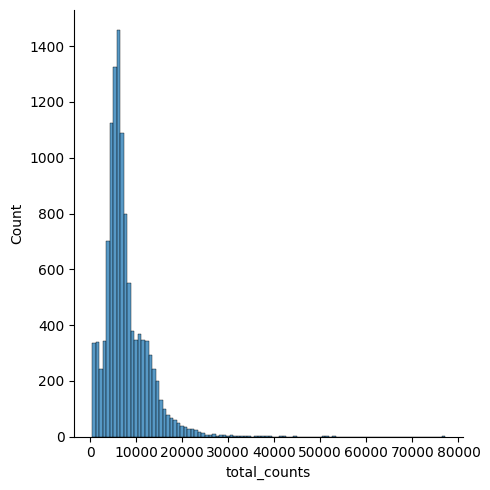

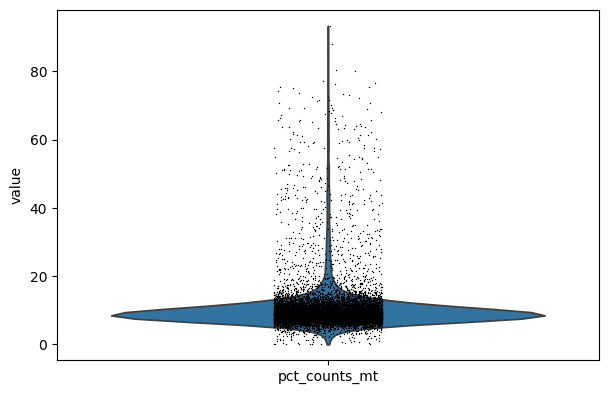

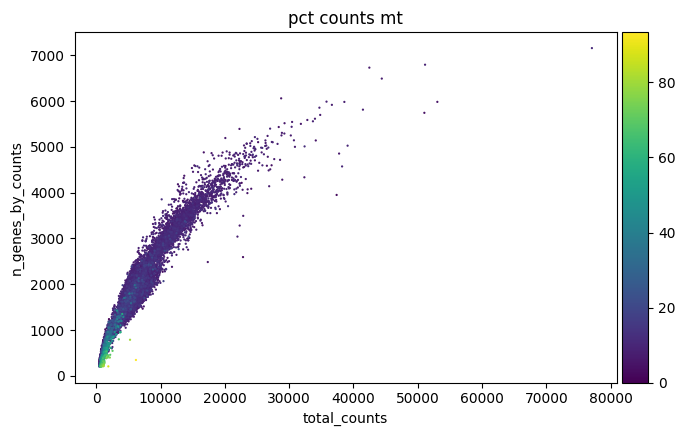

In [ ]:
adata = sc.read_h5ad('doublet_done_compressed.h5ad')

#creating plots of the data to determine filtration thresholds
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [ ]:
#remove doublets
print(f' Total number of cells before removing remaining doublets: {adata.X.shape}')
adata = adata[(adata.obs['doublet']==False)].copy()
print(f' Total number of cells after removing remaining doublets: {adata.X.shape}')

 Total number of cells before removing remaining doublets: (11536, 17526)
 Total number of cells after removing remaining doublets: (10195, 17526)


In [ ]:
#remove outliers using median absolute deviation
from scipy.stats import median_abs_deviation

def is_outlier(adata, metric: str, nmads: int):
  M = adata.obs[metric]
  outlier = (M < np.median(M) - (nmads * median_abs_deviation(M))) | (M > np.median(M) + (nmads * median_abs_deviation(M)))
  return outlier

#mt outlier only filters cells above the threshold
def is_mt_outlier(adata, metric: str, nmads: int):
  M = adata.obs[metric]
  outlier = (M > np.median(M) + (nmads * median_abs_deviation(M)))
  return outlier

adata.obs["outlier"] = (is_outlier(adata, "log1p_total_counts", 5)
                        | (is_outlier(adata, "log1p_n_genes_by_counts", 5)
                        | is_outlier(adata, "pct_counts_in_top_20_genes", 5))
                        )
adata.obs["mt_outlier"] = is_mt_outlier(adata, "pct_counts_mt", 3)

print(f' Total number of cells before removing outliers: {adata.X.shape}')
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()
print(f' Total number of cells after removing outliers: {adata.X.shape}')

 Total number of cells before removing outliers: (10195, 17526)
 Total number of cells after removing outliers: (8991, 17526)


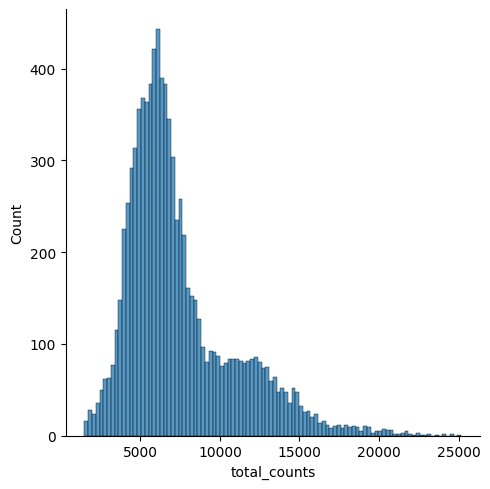

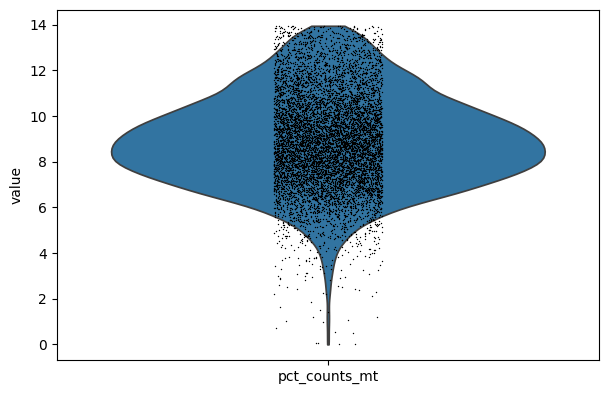

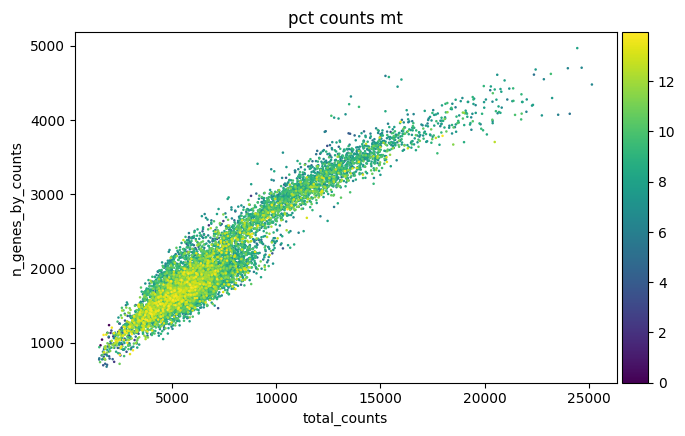

In [ ]:
#visualizing the data after filtering
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [ ]:
#normalizing with log1p as it is ideal for identifying differentially expressed genes
adata.layers['before_log1p'] = adata.X.copy()

#save a copy
adata.write_h5ad('filter_done_compressed.h5ad', compression = 'gzip') #file to use for annotation

In [4]:
adata = sc.read_h5ad('/content/PBMC10K/filter_done_compressed.h5ad')

#normalizing the data
sc.pp.normalize_total(adata, target_sum=None, inplace=True)
sc.pp.log1p(adata)

#feature selection using hvg
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3')

#pca for dimensionality reduction
sc.pp.pca(adata)

#build Knn graph for umap visualization and clustering
sc.pp.neighbors(adata, n_neighbors=30)

#embedding with umap
sc.tl.umap(adata)

In [ ]:
#Automated Annotation Using Celltypist

adata_celltypist = adata.copy()
adata_celltypist.X = adata.layers['before_soupx']
sc.pp.normalize_total(adata_celltypist, target_sum=10**4)
sc.pp.log1p(adata_celltypist)
adata_celltypist.X = adata_celltypist.X.toarray()

In [ ]:
#downloading the already trained models from celltypist
models.download_models(force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"])

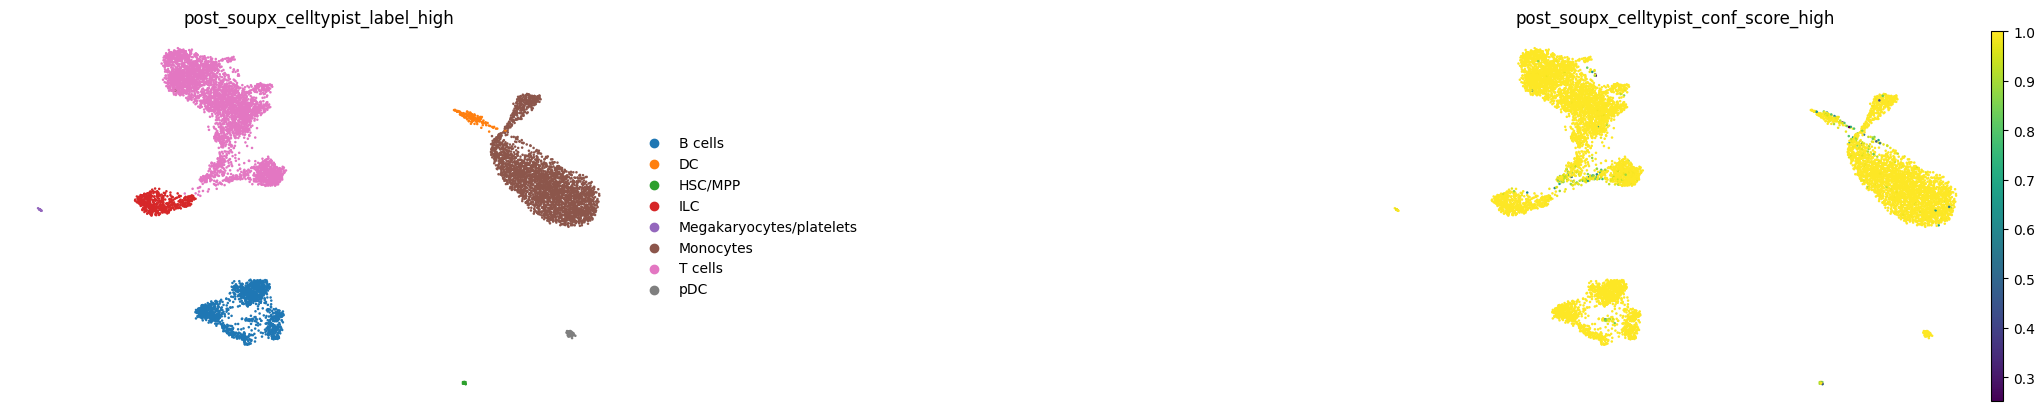

In [ ]:
model_low = models.Model.load(model = "Immune_All_Low.pkl")
model_high = models.Model.load(model = "Immune_All_High.pkl")

#for high
prediction_high = celltypist.annotate(adata_celltypist, model = model_high, majority_voting = True)
prediction_high_adata = prediction_high.to_adata()

adata.obs["post_soupx_celltypist_label_high"] = prediction_high_adata.obs.loc[adata.obs.index, "majority_voting"]
adata.obs["post_soupx_celltypist_conf_score_high"] = prediction_high_adata.obs.loc[adata.obs.index, "conf_score"]

#for low
prediction_low = celltypist.annotate(adata_celltypist, model = model_low, majority_voting = True)
prediction_low_adata = prediction_low.to_adata()

adata.obs["post_soupx_celltypist_label_low"] = prediction_low_adata.obs.loc[adata.obs.index, "majority_voting"]
adata.obs["post_soupx_celltypist_conf_score_low"] = prediction_low_adata.obs.loc[adata.obs.index, "conf_score"]

#Plot the automated annotation
sc.pl.umap(adata, color=["post_soupx_celltypist_label_high", "post_soupx_celltypist_conf_score_high"], frameon=False, sort_order=False, wspace=1)

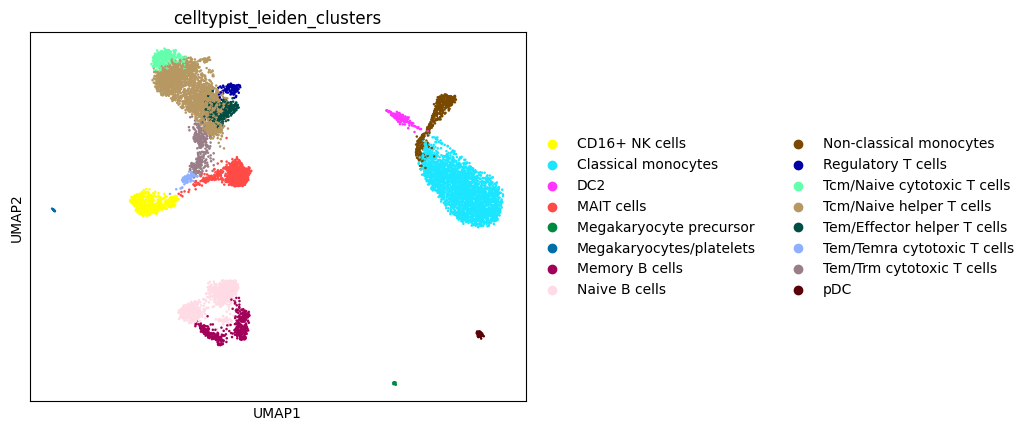

In [ ]:
adata.obs['celltypist_leiden_clusters'] = prediction_low.predicted_labels['majority_voting']
sc.pl.umap(adata, color='celltypist_leiden_clusters')

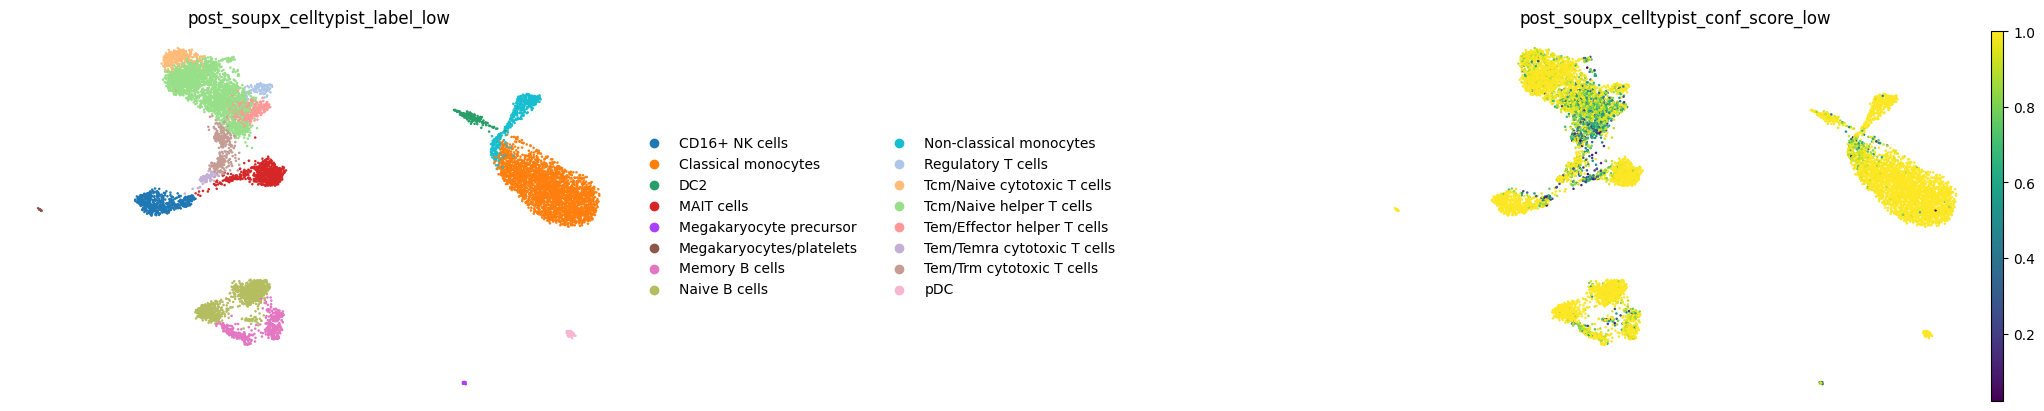

In [ ]:
#Plot the automated annotation
sc.pl.umap(adata, color=["post_soupx_celltypist_label_low", "post_soupx_celltypist_conf_score_low"], frameon=False, sort_order=False, wspace=1)

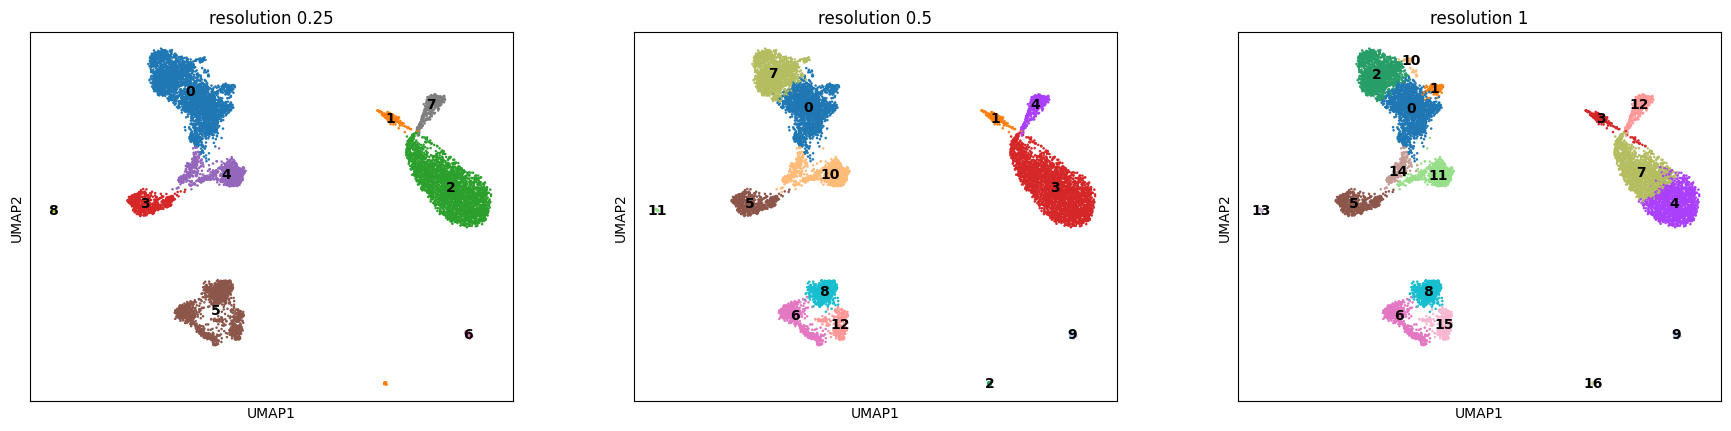

In [ ]:
#clustering with leiden
sc.tl.leiden(adata, key_added= 'resolution 0.25', flavor='igraph', n_iterations=2, resolution=0.25)
sc.tl.leiden(adata, key_added= 'resolution 0.5', flavor='igraph', n_iterations=2, resolution=0.5)
sc.tl.leiden(adata, key_added= 'resolution 1',
             flavor='igraph', n_iterations=2, resolution=1)

sc.pl.umap(adata, color=['resolution 0.25', 'resolution 0.5', 'resolution 1'], legend_loc="on data")

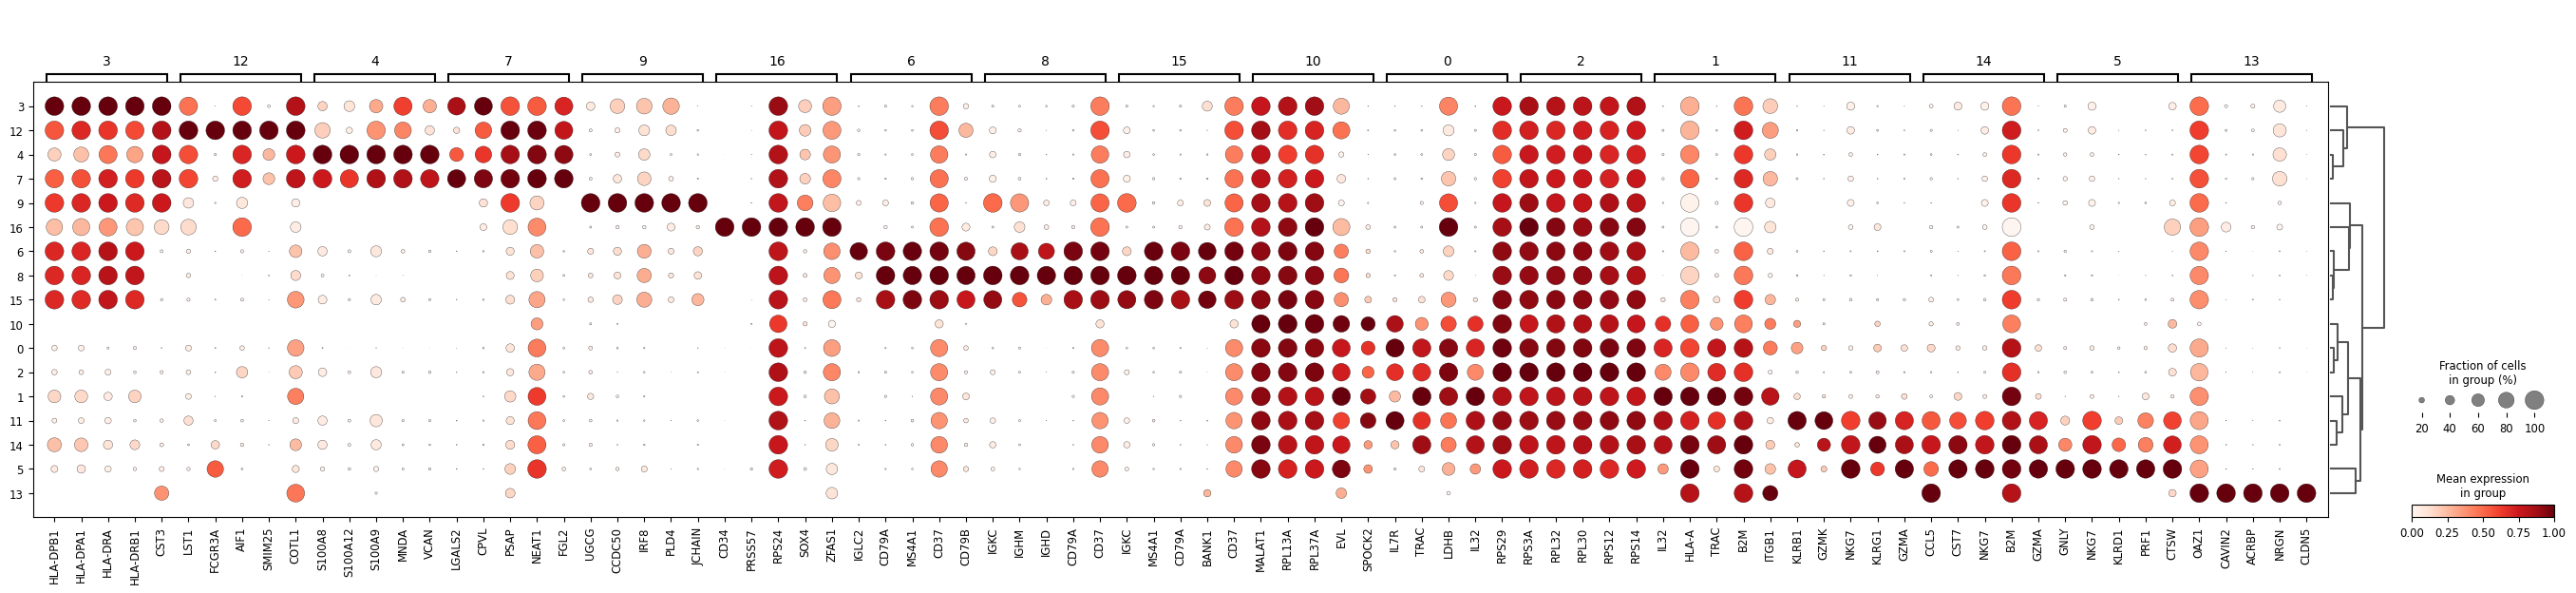

In [ ]:
#ranking the most prominent markers in each cluster for manual annotation
sc.tl.rank_genes_groups(adata, groupby='resolution 1', method='wilcoxon', key_added='dea_res_1')
sc.pl.rank_genes_groups_dotplot(adata, groupby='resolution 1', standard_scale='var', n_genes=5, key='dea_res_1')

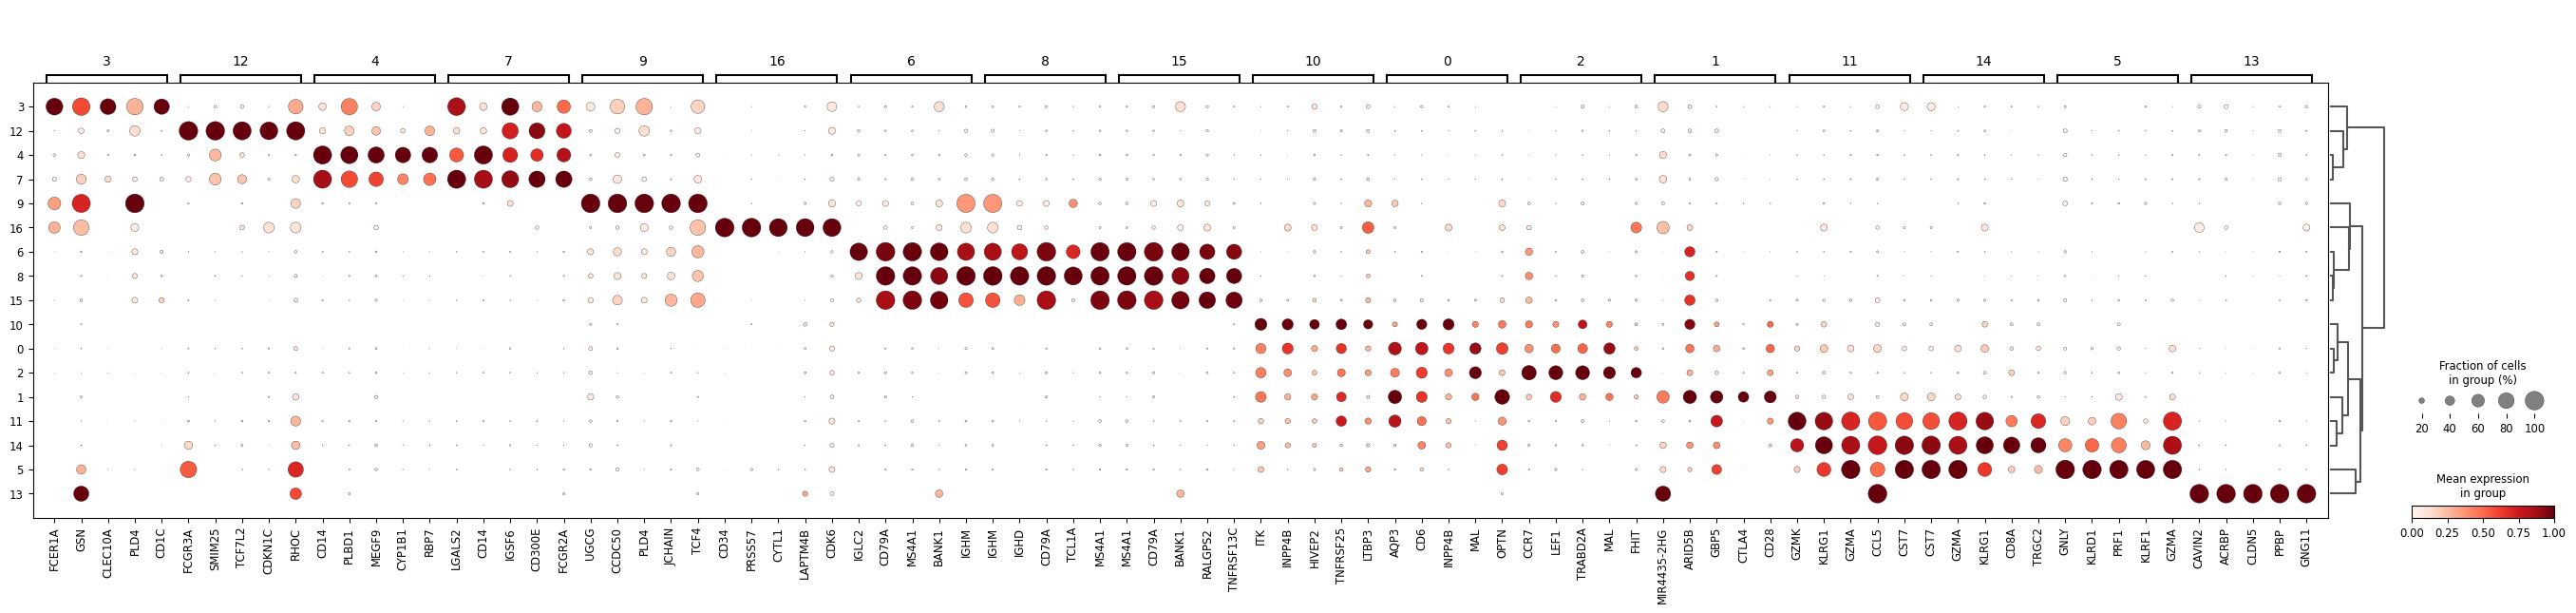

In [ ]:
sc.tl.filter_rank_genes_groups(adata,min_in_group_fraction=0.2, max_out_group_fraction=0.2, key='dea_res_1', key_added='dea_res_1_filtered')
sc.pl.rank_genes_groups_dotplot(adata, groupby='resolution 1', standard_scale='var', n_genes=5, key='dea_res_1_filtered')

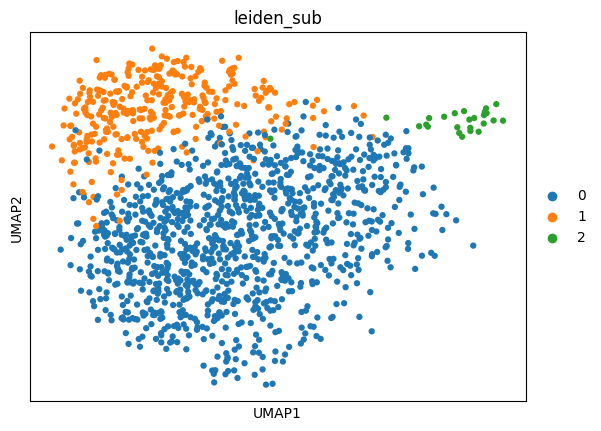

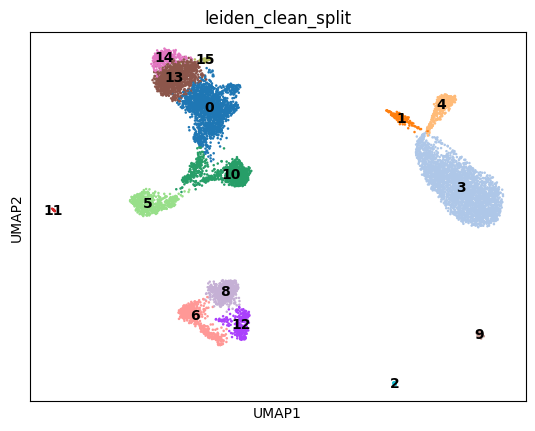

In [11]:
#to do sub clustering only on one cluster, i had an issue with cluster 7 in resolution 0.5 not being properly partition so i ran leiden on that one cluster
adata_subset = adata[adata.obs['resolution 0.5'].isin(['7'])].copy()
sc.pp.pca(adata_subset)
sc.pp.neighbors(adata_subset, n_neighbors=15, n_pcs=30)
sc.tl.leiden(adata_subset, resolution=0.25, key_added='leiden_sub')
sc.pl.umap(adata_subset, color=['leiden_sub'])
# 1. Create a copy of the original cluster column in metadata
adata.obs['leiden_split'] = adata.obs['resolution 0.5'].astype(str)

# Map the new sub-cluster labels into the original data column
# This replaces original cluster '3' with '3,0', '3,1', etc.
max_cluster = max(adata.obs['resolution 0.5'].astype(int))

# Map subclusters to new sequential integers (e.g., if max is 10, subclusters become 11, 12, etc.)
sub_map = {
    old: str(max_cluster + 1 + int(old))
    for old in adata_subset.obs['leiden_sub'].unique()
}
adata_subset.obs['leiden_new_nums'] = adata_subset.obs['leiden_sub'].map(sub_map)


# Transfer the new clean numbers back to the main data object
adata.obs['leiden_clean_split'] = adata.obs['resolution 0.5'].astype(str)
adata.obs.loc[adata_subset.obs_names, 'leiden_clean_split'] = adata_subset.obs['leiden_new_nums']
adata.obs['leiden_clean_split'] = adata.obs['leiden_clean_split'].astype('category')


# Plot the full global UMAP with clean, non-overlapping numbers
sc.pl.umap(adata, color='leiden_clean_split', legend_loc='on data')


In [16]:
#created a dictionary to map my manual annotations
cell_type ={
"0": "Helper CD4+ T Cells",
"1": "Inflammatory Dendritic Cells",
"2": "Hematopoeitic Stem Cells",
"3": "Classical Monocytes",
"4": "Non-Classical Monocytes",
"5": "Mature Cytotoxic NK Cells",
"6": "Mature Naive B Cells",
"8": "Naive B Cells",
"9": "Plasmacytoid Dendritic Cells",
"10": "Cytotoxic CD8+ Cells",
"11": "Platelets",
"12": "Memory B Cells",
"13": 'Naive CD4+ T Cells',
"14": 'Naive CD8+ T Cells',
"15": 'Helper CD4+ T Cells'
}

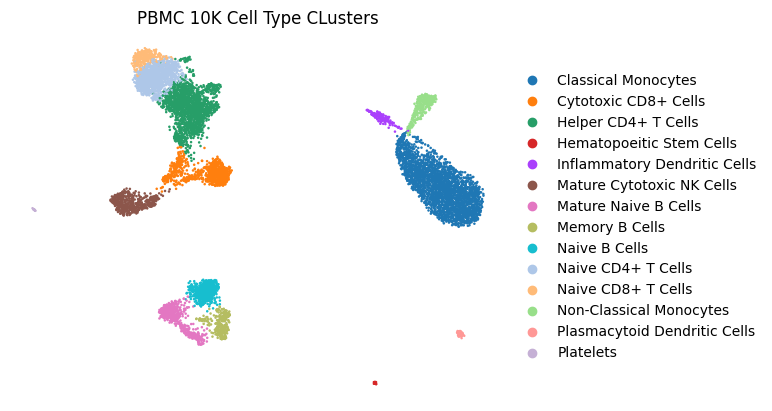

In [18]:
#mapped my manual annotations to the clusters on the umap
adata.obs['cell_type'] = adata.obs['leiden_clean_split'].map(cell_type)
sc.pl.umap(adata, color = ['cell_type'], frameon = False, title = 'PBMC 10K Cell Type CLusters')